In [ ]:
# Install required packages for HuggingFace downloads, polygon filtering, and visualisation
%pip install -q "huggingface_hub>=0.23.0" "pandas" "pillow" "tqdm" "geopandas" "shapely" "folium" "matplotlib"
print('Packages installed. Restart runtime if this is the first run, then re-execute from the next cell.')

Packages installed. Restart runtime if this is the first run, then re-execute from the next cell.


In [6]:
# ── Mount Google Drive ────────────────────────────────────────────────────────
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# ── Imports, configuration, and helpers ──────────────────────────────────────
import os
import json
import time
import zipfile
import tarfile
import warnings
from pathlib import Path

import pandas as pd
from PIL import Image
from tqdm.auto import tqdm
from huggingface_hub import hf_hub_download

# ── Global configuration — edit here only ────────────────────────────────────
BASE_DRIVE_DIR   = "/content/drive/MyDrive/Vision_Project_2026/osv5m/osv5m_italy_dataset"
HF_REPO_ID       = 'osv5m/osv5m'
HF_REPO_TYPE     = 'dataset'
USE_POLYGON_FILTER = True   # False -> simple bounding-box fallback
POLY_BUFFER_DEG  = 0.02     # buffer around Italy polygon for coastal points

# Optional: set this in Colab (or env) to improve HF download speed and limits.
# Example in a cell before this one:
#   import os
#   os.environ['HF_TOKEN'] = 'hf_xxx'
HF_TOKEN = os.environ.get('HF_TOKEN')

# Shards are first reused from Drive cache if present, then downloaded to
# a disposable runtime cache and deleted after each shard finishes.

# ── Directory setup ───────────────────────────────────────────────────────────
HF_CACHE_DIR  = os.path.join(BASE_DRIVE_DIR, 'hf_cache')
HF_META_DIR   = os.path.join(HF_CACHE_DIR,   'metadata')
DRIVE_SHARD_CACHE_DIR = os.path.join(HF_CACHE_DIR, 'archives')
SHARD_CACHE_DIR       = "/content/osv5m_shard_cache"
HF_ZIP_DIR            = SHARD_CACHE_DIR
SAVE_DIR_TRAIN = os.path.join(BASE_DRIVE_DIR, 'train_images')
SAVE_DIR_TEST  = os.path.join(BASE_DRIVE_DIR, 'test_images')

# How many images to extract per split.
# Set to None to extract ALL Italy images, or a number to cap the extraction.
TRAIN_IMAGE_LIMIT = None  # None = extract ALL Italy images
TEST_IMAGE_LIMIT  = None  # None = extract ALL Italy images

for d in [HF_META_DIR, DRIVE_SHARD_CACHE_DIR, HF_ZIP_DIR, SAVE_DIR_TRAIN, SAVE_DIR_TEST]:
    os.makedirs(d, exist_ok=True)

# ── Helpers ───────────────────────────────────────────────────────────────────
def _find_local(relative_path):
    for candidate in [
        Path(relative_path),
        Path(BASE_DRIVE_DIR) / relative_path,
        Path(HF_CACHE_DIR)   / relative_path,
    ]:
        if candidate.exists():
            return str(candidate)
    return None


def _hf_download(filename, subfolder=None, local_dir=HF_CACHE_DIR):
    """Download a file from HF only if not already cached locally."""
    rel = os.path.join('osv5m', subfolder, filename) if subfolder else os.path.join('osv5m', filename)
    existing = _find_local(rel)
    if existing:
        return existing
    local_path = os.path.join(local_dir, subfolder, filename) if subfolder else os.path.join(local_dir, filename)
    if os.path.exists(local_path):
        return local_path
    return hf_hub_download(
        repo_id=HF_REPO_ID,
        filename=filename,
        subfolder=subfolder,
        repo_type=HF_REPO_TYPE,
        local_dir=local_dir,
        token=HF_TOKEN,
    )


def load_split_csv(split, columns=None):
    """Load train.csv or test.csv. Pass columns=None to load ALL columns."""
    csv_path = (
        _find_local(os.path.join('osv5m', f'{split}.csv'))
        or _find_local(f'{split}.csv')
        or _hf_download(f'{split}.csv', local_dir=HF_META_DIR)
    )
    df = pd.read_csv(csv_path, low_memory=False, usecols=columns)
    df.columns = [c.lower() for c in df.columns]
    return df


def load_split_metadata(split):
    """Load only the columns needed for filtering, with normalised column names."""
    needed = {'id', 'image_id', 'latitude', 'longitude', 'lat', 'lon', 'country', 'status', 'wiki_url'}
    df = load_split_csv(split, columns=lambda c: c.lower() in needed)
    if 'image_id' not in df.columns and 'id'       in df.columns: df = df.rename(columns={'id':  'image_id'})
    if 'latitude'  not in df.columns and 'lat'      in df.columns: df = df.rename(columns={'lat': 'latitude'})
    if 'longitude' not in df.columns and 'lon'      in df.columns: df = df.rename(columns={'lon': 'longitude'})
    missing = {'image_id', 'latitude', 'longitude'} - set(df.columns)
    if missing:
        raise ValueError(f'{split}.csv is missing required columns: {missing}')
    if 'status' in df.columns:
        df = df[df['status'].astype(str).str.lower().isin(['success', 'ok', 'true', '1']) | df['status'].isna()]
    return df.dropna(subset=['image_id', 'latitude', 'longitude']).copy()


def _path_exists(path, retries=3, delay=2.0):
    """Drive-safe os.path.exists with retries."""
    if not path:
        return False
    for attempt in range(retries):
        try:
            return os.path.exists(path)
        except OSError:
            if attempt < retries - 1:
                time.sleep(delay)
    return False


def _safe_listdir(path, retries=3, delay=2.0):
    """Drive-safe os.listdir with retries; returns [] on persistent failure."""
    for attempt in range(retries):
        try:
            return os.listdir(path)
        except OSError as e:
            if attempt < retries - 1:
                print(f'Drive I/O error listing {path}, retrying ({attempt + 1}/{retries})...')
                time.sleep(delay)
            else:
                print(f'Could not list {path} after {retries} attempts: {e}. Treating as empty.')
                return []


def ensure_shard(split, shard_idx):
    """Return local path to a shard zip, downloading only if missing."""
    fname = f'{int(shard_idx):02d}.zip'
    candidates = [
        os.path.join(DRIVE_SHARD_CACHE_DIR, split, fname),
        os.path.join(DRIVE_SHARD_CACHE_DIR, fname),
        os.path.join(HF_ZIP_DIR, split, fname),
        _find_local(os.path.join('osv5m', 'images', split, fname)),
        _find_local(os.path.join('osv5m', 'archives', split, fname)),
    ]
    for candidate in candidates:
        if _path_exists(candidate):
            print(f'  Using cached shard: {candidate}')
            return candidate
    print(f'  [{split}] Downloading shard {shard_idx:02d} from HuggingFace...')
    downloaded = hf_hub_download(
        repo_id=HF_REPO_ID,
        filename=fname,
        subfolder=f'images/{split}',
        repo_type=HF_REPO_TYPE,
        local_dir=os.path.join(HF_ZIP_DIR, split),
        token=HF_TOKEN,
    )
    drive_copy = os.path.join(DRIVE_SHARD_CACHE_DIR, split, fname)
    os.makedirs(os.path.dirname(drive_copy), exist_ok=True)
    try:
        import shutil
        shutil.copy2(downloaded, drive_copy)
    except Exception:
        pass
    return downloaded


def is_temp_runtime_shard(path):
    """True if `path` is in the disposable runtime shard cache."""
    try:
        return os.path.commonpath([os.path.abspath(path), os.path.abspath(HF_ZIP_DIR)]) == os.path.abspath(HF_ZIP_DIR)
    except ValueError:
        return False


SHARD_COUNT = {'train': 98, 'test': 5}

# Images per split are spread across NUM_BUCKETS subdirectories to keep
# each folder under ~10 000 files (avoids Drive I/O errors on large dirs).
NUM_BUCKETS = 20

def _image_subdir(image_id):
    """Deterministic bucket folder for an image_id (00 .. NUM_BUCKETS-1)."""
    return f'{int(str(image_id)) % NUM_BUCKETS:02d}'


print('Configuration loaded.')

Configuration loaded.


In [ ]:
# ── Italy polygon setup ───────────────────────────────────────────────────────
# Builds the fastest available point-in-polygon tester: geopandas prepared
# geometry (best) → lightweight ray-casting fallback → bounding box.

italy_polygon       = None   # list of (lat, lon) tuples — ray-casting fallback
prepared_italy_geom = None   # shapely PreparedGeometry — preferred

_BBOX = dict(lat_min=36.6, lat_max=47.1, lon_min=6.6, lon_max=18.5)

_SAMPLE_POLYGON = [
    (47.1, 6.6), (47.1, 18.5), (45.0, 18.5), (43.5, 15.0),
    (41.0, 15.0), (38.0, 18.0), (38.0, 14.0), (36.0, 14.0), (36.0, 6.6),
]

def _ray_cast(lat, lon, polygon):
    inside, x, y, n = False, lon, lat, len(polygon)
    for i in range(n):
        j = (i - 1) % n
        yi, xi = polygon[i]; yj, xj = polygon[j]
        if ((xi > x) != (xj > x)) and (y < (yj - yi) * (x - xi) / (xj - xi + 1e-12) + yi):
            inside = not inside
    return inside

if USE_POLYGON_FILTER:
    try:
        import geopandas as gpd
        from shapely.prepared import prep
        with warnings.catch_warnings():
            warnings.simplefilter('ignore')
            try:
                _world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))
            except Exception:
                _world = gpd.read_file(
                    'https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip'
                )
            _col = next((c for c in _world.columns if c.upper() == 'NAME' and 'LONG' not in c.upper()), 'NAME')
            _geom = _world[_world[_col] == 'Italy'].geometry.iloc[0]
        if POLY_BUFFER_DEG > 0:
            _geom = _geom.buffer(POLY_BUFFER_DEG)
        prepared_italy_geom = prep(_geom)
        print('Italy polygon loaded from Natural Earth (shapely prepared geometry).')
    except Exception as e:
        print(f'geopandas unavailable ({e}); using ray-casting fallback.')
        italy_polygon = _SAMPLE_POLYGON
else:
    print('Polygon filter disabled; using bounding-box filter.')


def italy_mask(df):
    """Return a boolean Series: True for rows whose coordinates fall inside Italy."""
    if USE_POLYGON_FILTER and prepared_italy_geom is not None:
        from shapely.geometry import Point
        lats = df['latitude'].astype(float).values
        lons = df['longitude'].astype(float).values
        mask = [
            prepared_italy_geom.contains(Point(lon, lat))
            for lat, lon in tqdm(zip(lats, lons), total=len(df), desc='Filtering Italy', unit='rows')
        ]
        return pd.Series(mask, index=df.index)
    if USE_POLYGON_FILTER and italy_polygon is not None:
        return df.apply(
            lambda r: _ray_cast(float(r['latitude']), float(r['longitude']), italy_polygon),
            axis=1,
        )
    return (
        (df['latitude'].astype(float)  >= _BBOX['lat_min']) & (df['latitude'].astype(float)  <= _BBOX['lat_max']) &
        (df['longitude'].astype(float) >= _BBOX['lon_min']) & (df['longitude'].astype(float) <= _BBOX['lon_max'])
    )

Italy polygon loaded from Natural Earth (shapely prepared geometry).


In [ ]:
# ── Load CSVs, inspect columns, filter for Italy, save filtered manifests ─────

# --- 1. Show ALL columns from train.csv and test.csv ---
print('=' * 60)
print('TRAIN.CSV — all columns')
print('=' * 60)
try:
    _train_header = pd.read_csv(
        _hf_download('train.csv', local_dir=HF_META_DIR), nrows=3, low_memory=False
    )
    _train_header.columns = [c.lower() for c in _train_header.columns]
    print('Columns:', list(_train_header.columns))
    display(_train_header)
except Exception as e:
    print('Could not peek train.csv:', e)

print()
print('=' * 60)
print('TEST.CSV — all columns')
print('=' * 60)
try:
    _test_header = pd.read_csv(
        _hf_download('test.csv', local_dir=HF_META_DIR), nrows=3, low_memory=False
    )
    _test_header.columns = [c.lower() for c in _test_header.columns]
    print('Columns:', list(_test_header.columns))
    display(_test_header)
except Exception as e:
    print('Could not peek test.csv:', e)

# --- 2. Reuse filtered manifests if they already exist ---
TRAIN_FILTERED_CSV = os.path.join(BASE_DRIVE_DIR, 'train_filtered.csv')
TEST_FILTERED_CSV  = os.path.join(BASE_DRIVE_DIR, 'test_filtered.csv')

if os.path.exists(TRAIN_FILTERED_CSV) and os.path.exists(TEST_FILTERED_CSV):
    print()
    print('Found existing filtered manifests. Loading from Drive cache...')
    train_italy = pd.read_csv(TRAIN_FILTERED_CSV, low_memory=False)
    test_italy  = pd.read_csv(TEST_FILTERED_CSV, low_memory=False)
    print(f'Loaded train rows: {len(train_italy):,}')
    print(f'Loaded test  rows: {len(test_italy):,}')
else:
    # --- 3. Load metadata and filter to Italy (first run or missing cache) ---
    print()
    print('Filtered manifests not found (or incomplete). Building them now...')
    print('Loading full metadata for filtering...')
    train_df = load_split_metadata('train')
    test_df  = load_split_metadata('test')
    print(f'train.csv rows: {len(train_df):,}')
    print(f'test.csv  rows: {len(test_df):,}')

    print()
    print('Filtering train split...')
    train_italy = train_df[italy_mask(train_df)].copy()
    print(f'Italy train rows: {len(train_italy):,}')

    print()
    print('Filtering test split...')
    test_italy = test_df[italy_mask(test_df)].copy()
    print(f'Italy test rows: {len(test_italy):,}')

    # --- 4. Save filtered manifests to Drive ---
    _train_cols = [c for c in ['image_id', 'latitude', 'longitude', 'country', 'wiki_url'] if c in train_italy.columns]
    _test_cols  = [c for c in ['image_id', 'latitude', 'longitude', 'country', 'wiki_url'] if c in test_italy.columns]
    train_italy.to_csv(TRAIN_FILTERED_CSV, columns=_train_cols, index=False)
    test_italy.to_csv(TEST_FILTERED_CSV, columns=_test_cols, index=False)
    print(f'Saved: {TRAIN_FILTERED_CSV}')
    print(f'Saved: {TEST_FILTERED_CSV}')

TRAIN.CSV — all columns
Columns: ['id', 'latitude', 'longitude', 'thumb_original_url', 'country', 'sequence', 'captured_at', 'lon_bin', 'lat_bin', 'cell', 'region', 'sub-region', 'city', 'land_cover', 'road_index', 'drive_side', 'climate', 'soil', 'dist_sea', 'quadtree_10_5000', 'quadtree_10_25000', 'quadtree_10_1000', 'quadtree_10_50000', 'quadtree_10_12500', 'quadtree_10_500', 'quadtree_10_2500', 'unique_region', 'unique_sub-region', 'unique_city', 'unique_country', 'creator_username', 'creator_id']


,id,latitude,longitude,thumb_original_url,country,sequence,captured_at,lon_bin,lat_bin,cell,...,quadtree_10_50000,quadtree_10_12500,quadtree_10_500,quadtree_10_2500,unique_region,unique_sub-region,unique_city,unique_country,creator_username,creator_id
0,3859149887465501,-43.804769,-176.614093,https://scontent-cdg4-1.xx.fbcdn.net/m1/v/t6/A...,NZ,1qOCfogkQ5uE4ZvEf_4n2A,1547559856000,0,8,"(0, 8)",...,0,0,0,0,Chatham Islands_NZ,NaN,Waitangi_NaN_Chatham Islands_NZ,NZ,roadroid,1.113362e+14
1,574181207305439,-43.796611,-176.660483,https://scontent-cdg4-1.xx.fbcdn.net/m1/v/t6/A...,NZ,5rdtj6tui6qdlg8q812ul2,1567257056000,0,8,"(0, 8)",...,0,0,0,0,Chatham Islands_NZ,NaN,Waitangi_NaN_Chatham Islands_NZ,NZ,roadroid,1.113362e+14
2,333574322129026,-43.818092,-176.578383,https://scontent-cdg4-1.xx.fbcdn.net/m1/v/t6/A...,NZ,nJcst1M2bFUxSOA54CZiy9,1531231715132,0,8,"(0, 8)",...,0,0,0,0,Chatham Islands_NZ,NaN,Waitangi_NaN_Chatham Islands_NZ,NZ,roadroid,1.113362e+14



TEST.CSV — all columns
Columns: ['id', 'latitude', 'longitude', 'thumb_original_url', 'country', 'sequence', 'captured_at', 'lon_bin', 'lat_bin', 'cell', 'land_cover', 'road_index', 'drive_side', 'climate', 'soil', 'dist_sea', 'region', 'sub-region', 'city', 'unique_city', 'unique_sub-region', 'unique_region', 'unique_country', 'quadtree_10_1000', 'creator_username', 'creator_id']


,id,latitude,longitude,thumb_original_url,country,sequence,captured_at,lon_bin,lat_bin,cell,...,region,sub-region,city,unique_city,unique_sub-region,unique_region,unique_country,quadtree_10_1000,creator_username,creator_id
0,547473234108938,-16.336027,45.628280,https://scontent-cdg4-3.xx.fbcdn.net/m1/v/t6/A...,MG,Z2sJMyDVAtHBu7UFGvnYXg,1660909818797,61,28,"(61, 28)",...,Boeny,NaN,Sitampiky,Sitampiky_NaN_Boeny_MG,NaN,Boeny_MG,MG,1509,eric_s,1.078376e+14
1,826109781317024,50.855687,56.147997,https://scontent-cdg4-1.xx.fbcdn.net/m1/v/t6/A...,KZ,6cTpNBSYQH6SeDsfz_0mEQ,1548919530404,64,78,"(64, 78)",...,Aqtoebe,NaN,Martuk,Martuk_NaN_Aqtoebe_KZ,NaN,Aqtoebe_KZ,KZ,10995,vik1607,1.110825e+14
2,1006398440000844,37.956651,14.954485,https://scontent-cdg4-1.xx.fbcdn.net/m1/v/t6/A...,IT,xhcEpYg3dKnzts5ejIiSBJ,1658912403000,53,68,"(53, 68)",...,Sicily,Messina,Santa Domenica Vittoria,Santa Domenica Vittoria_Messina_Sicily_IT,Messina_Sicily_IT,Sicily_IT,IT,6488,gpsmapper,1.006127e+14



Found existing filtered manifests. Loading from Drive cache...
Loaded train rows: 111,787
Loaded test  rows: 1,397


In [ ]:
# ── Extract Italy images from HuggingFace shard zips ─────────────────────────
# Shards are downloaded one at a time, only Italy matches are kept, and only
# temporary runtime shard files are deleted after processing.

def process_split(split_name, split_df, limit, out_dir):
    """Extract up to `limit` Italy images (None = all) from shard zips."""
    os.makedirs(out_dir, exist_ok=True)
    metadata_csv = os.path.join(out_dir, f'{split_name}_metadata.csv')
    progress_json = os.path.join(out_dir, f'{split_name}_progress.json')

    # Resume: scan all subdirectory buckets for already-saved images
    already_saved = {p.stem for p in Path(out_dir).rglob('*.jpg')}
    print(f'{split_name}: {len(already_saved):,} images already on disk.')

    pending = {
        str(v) for v in split_df['image_id'].astype(str)
        if str(v) not in already_saved
    }
    if limit is not None:
        # Respect limit accounting for already-saved images
        remaining_budget = max(0, limit - len(already_saved))
        if remaining_budget == 0:
            print(f'{split_name}: limit of {limit:,} already reached, skipping extraction.')
            return pd.read_csv(metadata_csv) if os.path.exists(metadata_csv) else pd.DataFrame()
        pending = set(list(pending)[:remaining_budget])

    lookup = split_df.set_index(split_df['image_id'].astype(str))[['latitude', 'longitude']]
    saved_meta = []
    saved_count = 0
    total_shards = SHARD_COUNT[split_name]

    # Resume from last processed shard, but wrap once to avoid missing leftovers.
    start_shard = 0
    if os.path.exists(progress_json):
        try:
            with open(progress_json, 'r') as f:
                state = json.load(f)
            last_shard = int(state.get('last_processed_shard', -1))
            if -1 <= last_shard < total_shards:
                start_shard = last_shard + 1
        except Exception:
            start_shard = 0

    shard_order = list(range(start_shard, total_shards))
    if start_shard > 0:
        shard_order += list(range(0, start_shard))
        print(f'{split_name}: resuming from shard {start_shard:02d} (wrap enabled).')

    shard_progress = tqdm(shard_order, desc=f'{split_name} shards', unit='shard')

    for shard_idx in shard_progress:
        if not pending:
            break
        shard_progress.set_postfix(remaining=len(pending))
        print(f'  [{split_name}] Fetching shard {shard_idx:02d}/{total_shards - 1}...')
        zip_path = None
        try:
            zip_path = ensure_shard(split_name, shard_idx)
            with zipfile.ZipFile(zip_path, 'r') as zf:
                members = [m for m in zf.namelist() if m.lower().endswith('.jpg') and Path(m).stem in pending]
                for member in tqdm(members, desc=f'shard {shard_idx:02d}', unit='img', leave=False):
                    image_id = Path(member).stem
                    sub = _image_subdir(image_id)
                    os.makedirs(os.path.join(out_dir, sub), exist_ok=True)
                    out_path = os.path.join(out_dir, sub, f'{image_id}.jpg')
                    if not os.path.exists(out_path):
                        with zf.open(member) as src, open(out_path, 'wb') as dst:
                            dst.write(src.read())
                    row = lookup.loc[image_id]
                    saved_meta.append({
                        'id': image_id,
                        'latitude':  float(row['latitude']),
                        'longitude': float(row['longitude']),
                        'local_path': out_path,
                    })
                    pending.discard(image_id)
                    saved_count += 1

            with open(progress_json, 'w') as f:
                json.dump({'last_processed_shard': int(shard_idx)}, f)

        except Exception as e:
            print(f'  Shard {shard_idx:02d} unavailable: {e}')
            continue
        finally:
            # Do not delete Drive-cached shards; delete only runtime temp shards.
            if zip_path and os.path.exists(zip_path) and is_temp_runtime_shard(zip_path):
                try:
                    os.remove(zip_path)
                except OSError as cleanup_error:
                    print(f'  Could not delete shard cache {zip_path}: {cleanup_error}')

    # Append new rows to any existing metadata CSV
    new_df = pd.DataFrame(saved_meta)
    if os.path.exists(metadata_csv):
        existing_df = pd.read_csv(metadata_csv)
        new_df = pd.concat([existing_df, new_df], ignore_index=True).drop_duplicates(subset='id')
    new_df.to_csv(metadata_csv, index=False)
    print(f'{split_name}: {saved_count:,} new images saved. Metadata -> {metadata_csv}')
    return new_df


# print('Processing train split...')
# train_meta_df = process_split('train', train_italy, TRAIN_IMAGE_LIMIT, SAVE_DIR_TRAIN)

print()
print('Processing test split...')
test_meta_df = process_split('test', test_italy, TEST_IMAGE_LIMIT, SAVE_DIR_TEST)

print()
print('Image extraction complete.')


Processing test split...
test: 1,397 images already on disk.
test: resuming from shard 05 (wrap enabled).


test shards:   0%|          | 0/5 [00:00<?, ?shard/s]

test: 0 new images saved. Metadata -> /content/drive/MyDrive/Vision_Project_2026/osv5m/osv5m_italy_dataset/test_images/test_metadata.csv

Image extraction complete.


In [ ]:
# ── Migrate flat image directories to bucketed subdirectories ───────────────
# If you already extracted images into a flat folder (all JPGs at the top
# level), run this cell once to reorganise them into NUM_BUCKETS subfolders.
# Safe to re-run: skips images already in the right place.

def migrate_to_subdirs(image_dir, split_name):
    metadata_csv = os.path.join(image_dir, f'{split_name}_metadata.csv')

    flat_jpgs = [
        Path(image_dir) / f
        for f in _safe_listdir(image_dir)
        if f.lower().endswith('.jpg')
    ]
    if not flat_jpgs:
        print(f'{split_name}: no flat JPGs to migrate.')
        return

    print(f'{split_name}: migrating {len(flat_jpgs):,} flat images to subdirectories...')
    moved = 0
    for src_path in tqdm(flat_jpgs, desc=f'migrate {split_name}', unit='img'):
        image_id = src_path.stem
        sub = _image_subdir(image_id)
        dest_dir = Path(image_dir) / sub
        dest_dir.mkdir(exist_ok=True)
        dest_path = dest_dir / src_path.name
        if not dest_path.exists():
            src_path.rename(dest_path)
            moved += 1
    print(f'{split_name}: moved {moved:,} images into subdirectories.')

    # Update local_path column in metadata CSV
    if os.path.exists(metadata_csv):
        import pandas as pd
        df = pd.read_csv(metadata_csv)
        if 'local_path' in df.columns:
            def _new_path(row):
                iid = str(row['id'])
                return os.path.join(image_dir, _image_subdir(iid), f'{iid}.jpg')
            df['local_path'] = df.apply(_new_path, axis=1)
            df.to_csv(metadata_csv, index=False)
            print(f'{split_name}: updated local_path in {metadata_csv}')


migrate_to_subdirs(SAVE_DIR_TRAIN, 'train')
migrate_to_subdirs(SAVE_DIR_TEST,  'test')
print('Migration complete.')


train: migrating 111,787 flat images to subdirectories...


migrate train:   0%|          | 0/111787 [00:00<?, ?img/s]

train: moved 111,787 images into subdirectories.
train: updated local_path in /content/drive/MyDrive/Vision_Project_2026/osv5m/osv5m_italy_dataset/train_images/train_metadata.csv
test: migrating 1,397 flat images to subdirectories...


migrate test:   0%|          | 0/1397 [00:00<?, ?img/s]

test: moved 1,397 images into subdirectories.
test: updated local_path in /content/drive/MyDrive/Vision_Project_2026/osv5m/osv5m_italy_dataset/test_images/test_metadata.csv
Migration complete.


──────────────────────────────────────────────────
Italy train images available in CSV : 111,787
Italy train images extracted        : 111,787
Italy test  images available in CSV : 1,397
Italy test  images extracted        : 1,397
──────────────────────────────────────────────────


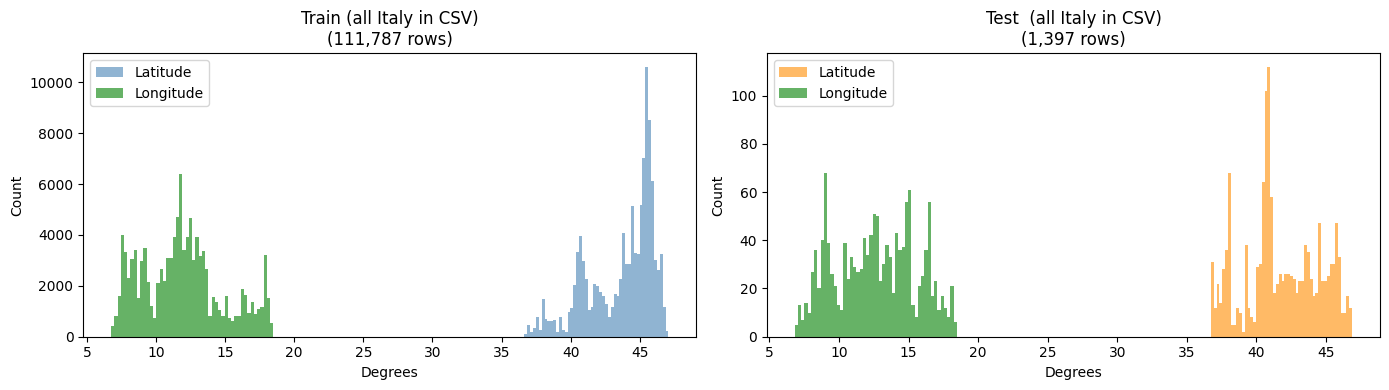

Histogram saved to Drive.
Interactive map saved to /content/drive/MyDrive/Vision_Project_2026/osv5m/osv5m_italy_dataset/italy_map.html


In [ ]:
# ── Statistics and geographic visualisation ───────────────────────────────────
import matplotlib.pyplot as plt
import folium
from IPython.display import display as ipy_display

# Load metadata if not already in memory
if 'train_meta_df' not in dir() or train_meta_df is None or len(train_meta_df) == 0:
    _p = os.path.join(SAVE_DIR_TRAIN, 'train_metadata.csv')
    train_meta_df = pd.read_csv(_p) if os.path.exists(_p) else pd.DataFrame()
if 'test_meta_df' not in dir() or test_meta_df is None or len(test_meta_df) == 0:
    _p = os.path.join(SAVE_DIR_TEST, 'test_metadata.csv')
    test_meta_df = pd.read_csv(_p) if os.path.exists(_p) else pd.DataFrame()

# ── Print summary counts ──────────────────────────────────────────────────────
print('─' * 50)
print(f'Italy train images available in CSV : {len(train_italy):,}')
print(f'Italy train images extracted        : {len(train_meta_df):,}')
print(f'Italy test  images available in CSV : {len(test_italy):,}')
print(f'Italy test  images extracted        : {len(test_meta_df):,}')
print('─' * 50)

# ── Latitude / Longitude histograms ──────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, df, label, color in [
    (axes[0], train_italy, 'Train (all Italy in CSV)', 'steelblue'),
    (axes[1], test_italy,  'Test  (all Italy in CSV)', 'darkorange'),
]:
    ax.hist(df['latitude'].astype(float),  bins=50, alpha=0.6, color=color,  label='Latitude')
    ax.hist(df['longitude'].astype(float), bins=50, alpha=0.6, color='green', label='Longitude')
    ax.set_title(f'{label}\n({len(df):,} rows)')
    ax.set_xlabel('Degrees')
    ax.set_ylabel('Count')
    ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(BASE_DRIVE_DIR, 'lat_lon_distribution.png'), dpi=100)
plt.show()
print('Histogram saved to Drive.')

# ── Folium map of extracted images ────────────────────────────────────────────
m = folium.Map(location=[42.5, 12.5], zoom_start=6, tiles='CartoDB positron')

# Train points (blue, max 2000 for performance)
_train_sample = train_meta_df.sample(min(2000, len(train_meta_df)), random_state=42) if len(train_meta_df) else train_meta_df
for _, row in _train_sample.iterrows():
    folium.CircleMarker(
        location=[row['latitude'], row['longitude']],
        radius=3, color='steelblue', fill=True, fill_opacity=0.5,
        popup=f"Train: {row.get('id', '')}",
    ).add_to(m)

# Test points (orange, max 500)
_test_sample = test_meta_df.sample(min(500, len(test_meta_df)), random_state=42) if len(test_meta_df) else test_meta_df
for _, row in _test_sample.iterrows():
    folium.CircleMarker(
        location=[row['latitude'], row['longitude']],
        radius=4, color='darkorange', fill=True, fill_opacity=0.7,
        popup=f"Test: {row.get('id', '')}",
    ).add_to(m)

# Legend via HTML
legend_html = """
<div style="position:fixed;bottom:30px;left:30px;z-index:1000;background:white;
            padding:8px 12px;border-radius:6px;border:1px solid #ccc;font-size:13px;">
  <b>Legend</b><br>
  <span style="color:steelblue;">&#9679;</span> Train (sampled)<br>
  <span style="color:darkorange;">&#9679;</span> Test (sampled)
</div>"""
m.get_root().html.add_child(folium.Element(legend_html))

map_path = os.path.join(BASE_DRIVE_DIR, 'italy_map.html')
m.save(map_path)
print(f'Interactive map saved to {map_path}')
ipy_display(m)

In [ ]:
# ── Create tar.gz archives of images + metadata, skip if already exist ────────

def make_archive(archive_path, image_dir, extra_csvs=()):
    if os.path.exists(archive_path):
        size_mb = os.path.getsize(archive_path) / 1e6
        print(f'Archive already exists ({size_mb:.1f} MB), skipping: {archive_path}')
        return
    print(f'Creating {archive_path} ...')
    with tarfile.open(archive_path, 'w:gz') as tar:
        images = [
            f for f in Path(image_dir).rglob('*')
            if f.suffix.lower() in ('.jpg', '.jpeg', '.png')
        ]
        for img in tqdm(images, desc='archiving images', unit='img'):
            tar.add(str(img), arcname=os.path.relpath(str(img), BASE_DRIVE_DIR))
        for csv_path in extra_csvs:
            if os.path.exists(csv_path):
                tar.add(csv_path, arcname=os.path.relpath(csv_path, BASE_DRIVE_DIR))
    size_mb = os.path.getsize(archive_path) / 1e6
    print(f'Done: {archive_path}  ({size_mb:.1f} MB)')


TRAIN_ARCHIVE = os.path.join(SAVE_DIR_TRAIN, 'osv5m_italy_train.tar.gz')
TEST_ARCHIVE  = os.path.join(SAVE_DIR_TEST,  'osv5m_italy_test.tar.gz')

make_archive(
    TRAIN_ARCHIVE,
    SAVE_DIR_TRAIN,
    extra_csvs=[
        os.path.join(SAVE_DIR_TRAIN, 'train_metadata.csv'),
        TRAIN_FILTERED_CSV,
    ],
)
make_archive(
    TEST_ARCHIVE,
    SAVE_DIR_TEST,
    extra_csvs=[
        os.path.join(SAVE_DIR_TEST, 'test_metadata.csv'),
        TEST_FILTERED_CSV,
    ],
)

print()
print('All archives ready.')
print(f'  Train: {TRAIN_ARCHIVE}')
print(f'  Test : {TEST_ARCHIVE}')

Creating /content/drive/MyDrive/Vision_Project_2026/osv5m/osv5m_italy_dataset/train_images/osv5m_italy_train.tar.gz ...


archiving images:   0%|          | 0/111787 [00:00<?, ?img/s]

In [7]:
# ── Transfer method benchmark ────────────────────────────────────────────────
# Tests 5 strategies for moving ~100K images from Drive to Colab.
# Run standalone — doesn't depend on the extraction cell.
# Results extrapolated to full dataset so you can pick the best method.

import os, time, shutil, zipfile, tarfile, random, json, io
from pathlib import Path
from PIL import Image

BENCH_N        = 500          # images to sample per test
BENCH_DIR      = '/content/osv5m_bench'
FULL_TRAIN_N   = 111_787

os.makedirs(BENCH_DIR, exist_ok=True)

IMAGES_ON_DRIVE = SAVE_DIR_TRAIN
SHARDS_ON_DRIVE = os.path.join(DRIVE_SHARD_CACHE_DIR, 'train')
META_CSV        = os.path.join(SAVE_DIR_TRAIN, 'train_metadata.csv')

results = {}

def _fmt(t, n_full):
    return f'{t:.1f}s  (full dataset: {t * n_full / BENCH_N / 60:.1f} min)'

def _read_images(paths):
    total = 0
    for p in paths:
        with open(p, 'rb') as f: data = f.read()
        total += len(data)
        Image.open(io.BytesIO(data)).convert('RGB')
    return total

# -- collect available JPGs --
jpg_files = []
try:
    jpg_files = [str(p) for p in Path(IMAGES_ON_DRIVE).rglob('*.jpg')]
    print(f'Found {len(jpg_files):,} extracted JPGs on Drive')
except Exception as e:
    print(f'Could not list extracted images: {e}')

sample = random.sample(jpg_files, min(BENCH_N, len(jpg_files))) if jpg_files else []

# ════════════════════════════════════════════════════════════
print('\n' + '='*60)
print('SCENARIO A — Read JPGs directly from Drive (no copy)')
print('='*60)
if sample:
    t0 = time.perf_counter()
    nb = _read_images(sample)
    elapsed = time.perf_counter() - t0
    results['A'] = elapsed
    print(f'  {len(sample)} imgs, {nb/1e6:.1f} MB => {_fmt(elapsed, FULL_TRAIN_N)}')
    print(f'  Throughput: {nb/1e6/elapsed:.1f} MB/s')
    print(f'  WARNING: this cost repeats every epoch!')
else:
    print('  Skipped: no extracted images found')

# ════════════════════════════════════════════════════════════
print('\n' + '='*60)
print('SCENARIO B — Bulk copy Drive JPGs -> /content (one-time)')
print('='*60)
if sample:
    dest_b = os.path.join(BENCH_DIR, 'b')
    shutil.rmtree(dest_b, ignore_errors=True); os.makedirs(dest_b)
    t0 = time.perf_counter()
    for src in sample:
        shutil.copy2(src, dest_b)
    t_copy = time.perf_counter() - t0
    nb_b = sum(os.path.getsize(os.path.join(dest_b, f)) for f in os.listdir(dest_b))
    print(f'  Copy: {nb_b/1e6:.1f} MB => {_fmt(t_copy, FULL_TRAIN_N)}')
    print(f'  Copy throughput: {nb_b/1e6/t_copy:.1f} MB/s')
    local_imgs = [os.path.join(dest_b, f) for f in os.listdir(dest_b)]
    t0 = time.perf_counter()
    _read_images(local_imgs)
    t_read = time.perf_counter() - t0
    print(f'  Read-back from /content: {_fmt(t_read, FULL_TRAIN_N)}')
    print(f'  Read throughput: {nb_b/1e6/t_read:.1f} MB/s')
    results['B_copy'] = t_copy
    results['B_read'] = t_read
else:
    print('  Skipped: no extracted images found')

# ════════════════════════════════════════════════════════════
print('\n' + '='*60)
print('SCENARIO C — Extract from Drive zip shards -> /content')
print('='*60)
try:
    shard_zips = sorted([os.path.join(SHARDS_ON_DRIVE, f)
                         for f in os.listdir(SHARDS_ON_DRIVE) if f.endswith('.zip')])
    if not shard_zips:
        raise FileNotFoundError(f'No zips in {SHARDS_ON_DRIVE}')
    dest_c = os.path.join(BENCH_DIR, 'c')
    shutil.rmtree(dest_c, ignore_errors=True); os.makedirs(dest_c)
    target_ids = {Path(p).stem for p in sample} if sample else set()
    if not target_ids:
        # grab first BENCH_N image IDs from shards
        print('  No extracted images; sampling IDs directly from first shard...')
        with zipfile.ZipFile(shard_zips[0], 'r') as zf:
            target_ids = {Path(m).stem for m in zf.namelist()
                          if m.lower().endswith('.jpg')}.__class__(list(
                              {Path(m).stem for m in zf.namelist()
                               if m.lower().endswith('.jpg')})[:BENCH_N])
    extracted = 0; nb_c = 0
    t0 = time.perf_counter()
    for zpath in shard_zips:
        if extracted >= BENCH_N: break
        with zipfile.ZipFile(zpath, 'r') as zf:
            members = [m for m in zf.namelist()
                       if m.lower().endswith('.jpg') and Path(m).stem in target_ids]
            for m in members:
                if extracted >= BENCH_N: break
                data = zf.read(m)
                with open(os.path.join(dest_c, Path(m).name), 'wb') as f: f.write(data)
                nb_c += len(data); extracted += 1
    elapsed_c = time.perf_counter() - t0
    results['C'] = elapsed_c
    print(f'  Extracted {extracted} imgs ({nb_c/1e6:.1f} MB) => {_fmt(elapsed_c, FULL_TRAIN_N)}')
    print(f'  Throughput: {nb_c/1e6/elapsed_c:.1f} MB/s')
    print(f'  Note: one-time per Colab session, then read from /content at full speed.')
except Exception as e:
    print(f'  Skipped: {e}')

# ════════════════════════════════════════════════════════════
print('\n' + '='*60)
print('SCENARIO D — Uncompressed tar on Drive -> copy -> extract')
print('='*60)
if sample:
    tar_drive = os.path.join(BASE_DRIVE_DIR, '_bench.tar')
    tar_local = os.path.join(BENCH_DIR, '_bench.tar')
    dest_d = os.path.join(BENCH_DIR, 'd')
    shutil.rmtree(dest_d, ignore_errors=True); os.makedirs(dest_d)
    try:
        t0 = time.perf_counter()
        with tarfile.open(tar_drive, 'w') as tar:  # 'w' = no compression
            for src in sample:
                tar.add(src, arcname=Path(src).name)
        t_create = time.perf_counter() - t0
        sz = os.path.getsize(tar_drive) / 1e6
        print(f'  Create tar ({sz:.1f} MB): {t_create:.1f}s ({sz/t_create:.1f} MB/s)')

        t0 = time.perf_counter()
        shutil.copy2(tar_drive, tar_local)
        t_copy = time.perf_counter() - t0
        print(f'  Copy to /content: {t_copy:.1f}s ({sz/t_copy:.1f} MB/s)')

        t0 = time.perf_counter()
        with tarfile.open(tar_local, 'r') as tar: tar.extractall(dest_d)
        t_extract = time.perf_counter() - t0
        print(f'  Extract: {t_extract:.1f}s')

        total_d = t_create + t_copy + t_extract
        results['D'] = total_d
        scale = FULL_TRAIN_N / BENCH_N
        print(f'  Total one-time: {total_d:.1f}s')
        print(f'  Extrapolated: create {t_create*scale/60:.1f}m + copy {t_copy*scale/60:.1f}m + extract {t_extract*scale/60:.1f}m')
    finally:
        for p in [tar_drive, tar_local]:
            if os.path.exists(p): os.remove(p)
else:
    print('  Skipped: no extracted images found')

# ════════════════════════════════════════════════════════════
print('\n' + '='*60)
print('SCENARIO E — WebDataset tar shards (best for DataLoader)')
print('='*60)
try:
    import importlib.util
    if importlib.util.find_spec('webdataset') is None:
        import subprocess; subprocess.check_call(['pip', 'install', '-q', 'webdataset'])
    import webdataset as wds
    import pandas as pd

    meta = pd.read_csv(META_CSV) if os.path.exists(META_CSV) else None
    wds_drive = os.path.join(BASE_DRIVE_DIR, '_bench_wds')
    wds_local = os.path.join(BENCH_DIR, 'e')
    os.makedirs(wds_drive, exist_ok=True)
    shutil.rmtree(wds_local, ignore_errors=True); os.makedirs(wds_local)

    shard_path = os.path.join(wds_drive, 'bench-00000.tar')
    src_list = sample if sample else []
    if not src_list:
        raise RuntimeError('Need extracted images for WDS write benchmark')

    t0 = time.perf_counter()
    with wds.TarWriter(shard_path) as sink:
        for src in src_list:
            img_id = Path(src).stem
            with open(src, 'rb') as f: jpg_bytes = f.read()
            entry = {'__key__': img_id, 'jpg': jpg_bytes}
            if meta is not None:
                row = meta[meta['id'].astype(str) == img_id]
                if len(row):
                    entry['json'] = json.dumps({
                        'latitude':  float(row.iloc[0]['latitude']),
                        'longitude': float(row.iloc[0]['longitude']),
                    }).encode()
            sink.write(entry)
    t_write = time.perf_counter() - t0
    sz_e = os.path.getsize(shard_path) / 1e6
    print(f'  Write WDS shard ({sz_e:.1f} MB): {t_write:.1f}s ({sz_e/t_write:.1f} MB/s)')

    local_shard = os.path.join(wds_local, 'bench-00000.tar')
    t0 = time.perf_counter()
    shutil.copy2(shard_path, local_shard)
    t_copy_e = time.perf_counter() - t0
    print(f'  Copy to /content: {t_copy_e:.1f}s ({sz_e/t_copy_e:.1f} MB/s)')

    t0 = time.perf_counter()
    ds = wds.WebDataset(local_shard).decode('pil').to_tuple('jpg', 'json')
    count = sum(1 for img, _ in ds if img.convert('RGB') is not None)
    t_stream = time.perf_counter() - t0
    print(f'  Stream {count} samples (simulated training): {t_stream:.1f}s ({sz_e/t_stream:.1f} MB/s)')

    results['E_setup'] = t_write + t_copy_e
    results['E_per_epoch'] = t_stream
    scale = FULL_TRAIN_N / BENCH_N
    print(f'  Extrapolated: write {t_write*scale/60:.1f}m + copy {t_copy_e*scale/60:.1f}m (one-time)')
    print(f'               stream per epoch: {t_stream*scale/60:.1f} min')
    shutil.rmtree(wds_drive, ignore_errors=True)
except Exception as e:
    print(f'  Skipped: {e}')

# ════════════════════════════════════════════════════════════
print('\n' + '='*60)
print('SUMMARY')
print('='*60)
scale = FULL_TRAIN_N / BENCH_N
rows = [
    ('A', 'Drive direct (per-epoch cost)',      results.get('A')),
    ('B', 'Copy JPGs + read from /content',     results.get('B_copy')),
    ('C', 'Extract zip shards -> /content',     results.get('C')),
    ('D', 'Uncompressed tar (create+copy+ext)', results.get('D')),
    ('E', 'WebDataset (write+copy one-time)',    results.get('E_setup')),
    ('E', 'WebDataset (per-epoch stream)',       results.get('E_per_epoch')),
]
for key, label, t in rows:
    if t is not None:
        print(f'  {key}  {label:<42} {t:.1f}s sample -> {t*scale/60:.1f} min full')
print()
print('RECOMMENDATION:')
print('  Best one-time setup  : C (extract from existing Drive zip shards)')
print('  Best multi-epoch use : E (WebDataset — write once, stream fast each epoch)')
print('  Simplest if extracted: B (bulk copy JPGs to /content)')
print('  Avoid               : A (Drive random read bottleneck per epoch)')
print('  Avoid               : tar.gz (gz compression is the slow part)')


Found 113,139 extracted JPGs on Drive

SCENARIO A — Read JPGs directly from Drive (no copy)


FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/Vision_Project_2026/osv5m/osv5m_italy_dataset/train_images/1435969493410810.jpg'

In [8]:
# ── Archive subdirs -> copy to runtime -> extract ────────────────────────────
# One-time per Colab session.
#   1. Creates one uncompressed tar per subdir on Drive (cached; skipped if up-to-date).
#   2. Copies each tar to /content and extracts it.
# After this cell, all images live under RUNTIME_TRAIN_DIR / RUNTIME_TEST_DIR
# with the same NN/image_id.jpg layout, readable at full local speed.

import os, tarfile, shutil, time
from pathlib import Path
from tqdm.auto import tqdm

RUNTIME_BASE      = '/content/osv5m_images'
RUNTIME_TRAIN_DIR = os.path.join(RUNTIME_BASE, 'train')
RUNTIME_TEST_DIR  = os.path.join(RUNTIME_BASE, 'test')
TAR_CACHE_TRAIN   = os.path.join(BASE_DRIVE_DIR, 'train_subdirtars')
TAR_CACHE_TEST    = os.path.join(BASE_DRIVE_DIR, 'test_subdirtars')

for d in [RUNTIME_TRAIN_DIR, RUNTIME_TEST_DIR, TAR_CACHE_TRAIN, TAR_CACHE_TEST]:
    os.makedirs(d, exist_ok=True)


def _subdir_tar_path(tar_cache_dir, bucket):
    return os.path.join(tar_cache_dir, f'{bucket}.tar')


def _make_subdir_tar(src_dir, tar_path):
    """Create uncompressed tar of src_dir. Skip if tar is already up-to-date."""
    images = list(Path(src_dir).glob('*.jpg'))
    if not images:
        return 0
    # Skip if tar exists and is newer than the newest image
    if os.path.exists(tar_path):
        tar_mtime = os.path.getmtime(tar_path)
        newest_img = max(p.stat().st_mtime for p in images)
        if tar_mtime >= newest_img:
            return len(images)  # up-to-date
    with tarfile.open(tar_path, 'w') as tar:
        for img in images:
            tar.add(str(img), arcname=img.name)
    return len(images)


def deploy_split(split_name, image_dir, tar_cache_dir, runtime_dir):
    t_total = time.perf_counter()
    buckets = sorted([
        d for d in os.listdir(image_dir)
        if os.path.isdir(os.path.join(image_dir, d)) and d.isdigit()
    ])
    if not buckets:
        print(f'[{split_name}] No bucket subdirectories found in {image_dir}.')
        print(f'[{split_name}] Run the extraction cell (and migration cell) first.')
        return

    print(f'[{split_name}] {len(buckets)} buckets found: {buckets[0]} .. {buckets[-1]}')

    t_create = t_copy = t_extract = 0.0
    total_images = 0
    total_bytes  = 0

    for bucket in tqdm(buckets, desc=f'{split_name} buckets', unit='bucket'):
        src_dir  = os.path.join(image_dir, bucket)
        tar_path = _subdir_tar_path(tar_cache_dir, bucket)
        tmp_tar  = f'/content/_osv5m_{split_name}_{bucket}.tar'
        dest_dir = os.path.join(runtime_dir, bucket)
        os.makedirs(dest_dir, exist_ok=True)

        # -- already extracted? count existing images --
        existing = list(Path(dest_dir).glob('*.jpg'))
        src_images = list(Path(src_dir).glob('*.jpg'))
        if len(existing) >= len(src_images) and src_images:
            total_images += len(existing)
            continue  # bucket already on runtime

        # Step 1: create/update tar on Drive
        t0 = time.perf_counter()
        n = _make_subdir_tar(src_dir, tar_path)
        t_create += time.perf_counter() - t0
        if n == 0:
            continue

        # Step 2: copy tar to runtime
        t0 = time.perf_counter()
        shutil.copy2(tar_path, tmp_tar)
        sz = os.path.getsize(tmp_tar)
        t_copy += time.perf_counter() - t0
        total_bytes += sz

        # Step 3: extract into runtime subdir
        t0 = time.perf_counter()
        with tarfile.open(tmp_tar, 'r') as tar:
            tar.extractall(dest_dir)
        t_extract += time.perf_counter() - t0
        total_images += n

        os.remove(tmp_tar)

    elapsed = time.perf_counter() - t_total
    mb = total_bytes / 1e6
    print(f'[{split_name}] {total_images:,} images ready in {elapsed:.1f}s  '
          f'(create {t_create:.1f}s | copy {t_copy:.1f}s @ {mb/(t_copy or 1e-9):.0f} MB/s | '
          f'extract {t_extract:.1f}s)')
    print(f'[{split_name}] Images at: {runtime_dir}')


deploy_split('train', SAVE_DIR_TRAIN, TAR_CACHE_TRAIN, RUNTIME_TRAIN_DIR)
deploy_split('test',  SAVE_DIR_TEST,  TAR_CACHE_TEST,  RUNTIME_TEST_DIR)

print()
print('Runtime paths (use these in your training notebook):')
print(f'  RUNTIME_TRAIN_DIR = {repr(RUNTIME_TRAIN_DIR)}')
print(f'  RUNTIME_TEST_DIR  = {repr(RUNTIME_TEST_DIR)}')
print(f'  Layout: <dir>/<bucket_00-19>/<image_id>.jpg')


[train] 20 buckets found: 00 .. 19


train buckets:   0%|          | 0/20 [00:00<?, ?bucket/s]

/tmp/ipykernel_4722/1130639504.py:91: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(dest_dir)


[train] 95,542 images ready in 3196.8s  (create 2946.7s | copy 29.5s @ 171 MB/s | extract 66.3s)
[train] Images at: /content/osv5m_images/train
[test] 20 buckets found: 00 .. 19


test buckets:   0%|          | 0/20 [00:00<?, ?bucket/s]

[test] 1,397 images ready in 334.3s  (create 332.7s | copy 0.3s @ 261 MB/s | extract 0.5s)
[test] Images at: /content/osv5m_images/test

Runtime paths (use these in your training notebook):
  RUNTIME_TRAIN_DIR = '/content/osv5m_images/train'
  RUNTIME_TEST_DIR  = '/content/osv5m_images/test'
  Layout: <dir>/<bucket_00-19>/<image_id>.jpg
